$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Data:}$ 12/07/2025

# Trabalho de Simulação

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import scipy.stats as stats
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.optimize import minimize
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

In [2]:
rng = np.random.default_rng(seed=4)

# Modelos

## AR
$ y_t = \phi y_{t-1} + \varepsilon_t,   \varepsilon_t \sim N(0, \sigma^2)
$ e $p(y_1) \sim N(a_1, P_1)
$

In [3]:
T = 100 # número de observações
ϕ, σ = 0.8, 1.5 # parâmetros reais

ϵt = rng.normal(0, σ, size=T)
y_true = np.zeros(T)

for t in range(1, T):
    y_true[t] = ϕ*y_true[t-1] + ϵt[t]

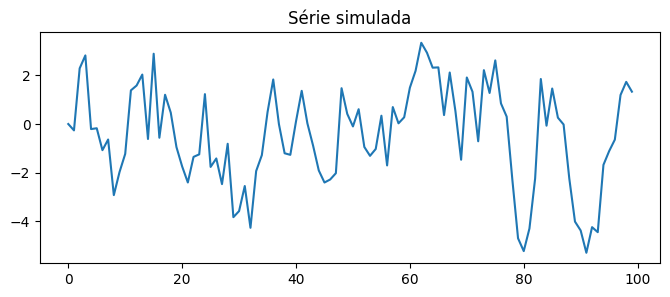

In [4]:
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.arange(len(y_true)), y_true)
ax.set_title('Série simulada')
plt.show()

### Funções

In [5]:
def run_model(ϕ, σ, T, N):
    a1, P1 = 0, σ**2/(1 - ϕ**2)
    
    ϵt = rng.normal(0, σ, size=(N,T))
    y1 = rng.normal(loc=a1, scale=np.sqrt(P1), size=N)
    
    yt = np.zeros((N,T))
    yt[:,0] = y1
    
    for t in range(1, T):
        yt[:,t] = ϕ*yt[:,t-1] + ϵt[:,t]
            
    yt_hat = np.mean(yt, axis=0) # média da densidade simulada
    Ft = np.mean(np.power(yt - yt_hat, 2), axis=0) # variância da densidade estimada
    vt = y_true - yt_hat # inovações
    
    return yt_hat, vt, Ft

In [6]:
def neg_log_likelihood(theta, y_true, N=1000):
    # ϕ, σ = theta
    ϕ, log_σ = theta
    σ = np.exp(log_σ)
    T = len(y_true)
    
    yt_hat, vt, Ft = run_model(ϕ, σ, T, N)    
    log_likelihood = (
        -T/2 * np.log(2 * np.pi)
        -0.5 * np.sum(np.log(Ft) + np.power(vt, 2)/Ft)
    )
    return -log_likelihood

In [7]:
neg_log_likelihood((0.8, np.log(1.5)), y_true)

217.93877196604257

### Otimização BFGS

In [8]:
def callback_function(xk):
    print("Iteration:", callback_function.iteration)
    print("Loss function value:", neg_log_likelihood(xk, y_true))
    print("Optimized parameters:", xk)
    print("-" * 85)
    callback_function.iteration += 1
    parameters.append(xk)

In [9]:
bounds_= [(-0.999, 0.999),(1e-6, None)]
initial_guess = np.array([0.2, np.log(10)])
parameters = [initial_guess.copy()]

callback_function.iteration = 1
result = minimize(
    neg_log_likelihood,
    x0 = initial_guess,
    args = (y_true, 10000),
    callback = callback_function,
    method = "L-BFGS-B",
    bounds = bounds_,
    tol = 1e-6,
    options = {'maxiter': 200},
)
result

Iteration: 1
Loss function value: 326.02745984658793
Optimized parameters: [0.2        2.30258516]
-------------------------------------------------------------------------------------
Iteration: 2
Loss function value: 326.10784018597786
Optimized parameters: [0.2        2.30258516]
-------------------------------------------------------------------------------------


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 326.28044470857964
        x: [ 2.000e-01  2.303e+00]
      nit: 2
      jac: [-1.269e+06 -5.787e+06]
     nfev: 69
     njev: 23
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [10]:
ϕ_hat, log_σ_hat = result.x
σ_hat = np.exp(log_σ_hat)
ϕ_hat, σ_hat

(0.19999999999999274, 10.000000694641974)

### Otimização por Nelder-Mead

In [11]:
bounds_ = [(-0.999, 0.999), (np.log(1e-6), np.log(100))]
initial_guess = np.array([0.7, np.log(10)])

callback_function.iteration = 1
result = minimize(
    neg_log_likelihood,
    x0=initial_guess,
    args=(y_true, 10000),
    callback = callback_function,
    method="Nelder-Mead", 
    bounds=bounds_,
    tol = 1e-6,
    options={"maxiter": 200},
)

Iteration: 1
Loss function value: 342.7339545553189
Optimized parameters: [0.7525     2.07232658]
-------------------------------------------------------------------------------------
Iteration: 2
Loss function value: 325.354975844714
Optimized parameters: [0.70875    1.95719733]
-------------------------------------------------------------------------------------
Iteration: 3
Loss function value: 290.3540937593372
Optimized parameters: [0.791875   1.43911568]
-------------------------------------------------------------------------------------
Iteration: 4
Loss function value: 242.3345682164885
Optimized parameters: [0.7459375  0.94981635]
-------------------------------------------------------------------------------------
Iteration: 5
Loss function value: 222.03348568112364
Optimized parameters: [0.8290625 0.4317347]
-------------------------------------------------------------------------------------
Iteration: 6
Loss function value: 222.13188904820993
Optimized parameters: [0.8290

In [12]:
ϕ_hat, log_σ_hat = result.x
σ_hat = np.exp(log_σ_hat)
ϕ_hat, σ_hat

(0.835882243480411, 1.1112806505196284)

In [13]:
yt_hat, vt, _ = run_model(ϕ_hat, σ_hat, T=len(y_true), N=1000)
neg_log_likelihood((ϕ_hat, log_σ_hat), y_true)

215.37646519600827

### Resultados

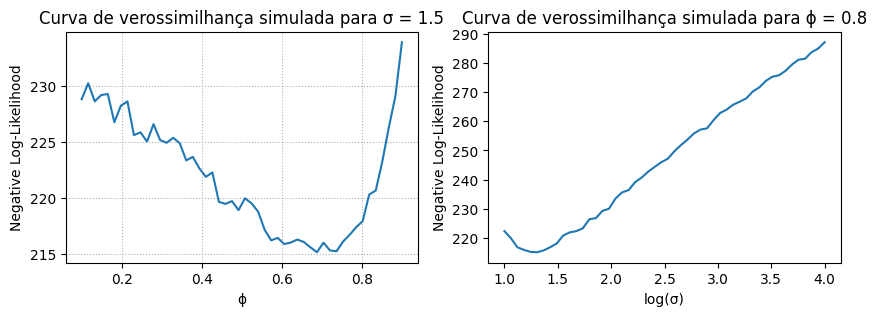

In [14]:
fig, ax = plt.subplots(1,2, figsize=(10,3))

ϕ_grid = np.linspace(0.1, 0.9, 50)
losses = [neg_log_likelihood([phi, np.log(σ)], y_true, N=1000) for phi in ϕ_grid]
ax[0].plot(ϕ_grid, losses)
ax[0].set_xlabel("ϕ")
ax[0].set_ylabel("Negative Log-Likelihood")
ax[0].set_title("Curva de verossimilhança simulada para σ = {}".format(σ))
ax[0].grid(axis='both', linestyle=':')

sigma_grid = np.linspace(1, 4, 50)
losses = [neg_log_likelihood([ϕ, np.log(sigma)], y_true, N=1000) for sigma in sigma_grid]
ax[1].plot(sigma_grid, losses)
ax[1].set_xlabel("log(σ)")
ax[1].set_ylabel("Negative Log-Likelihood")
ax[1].set_title("Curva de verossimilhança simulada para ϕ = {}".format(ϕ))

plt.show()

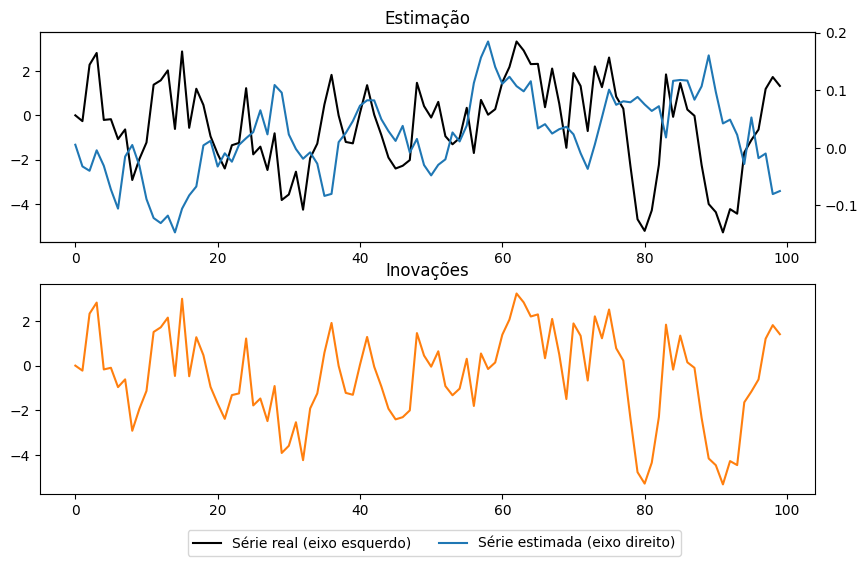

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(10,6))
ax[0].plot(np.arange(T), y_true, label='Série real (eixo esquerdo)', color='black')
ax2 = ax[0].twinx()
ax2.plot(np.arange(T), yt_hat, label='Série estimada (eixo direito)')
ax[0].set_title('Estimação')

ax[1].plot(np.arange(T), vt, color='C1')
ax[1].set_title('Inovações')
fig.legend(loc='lower center', ncol=2)
plt.show()

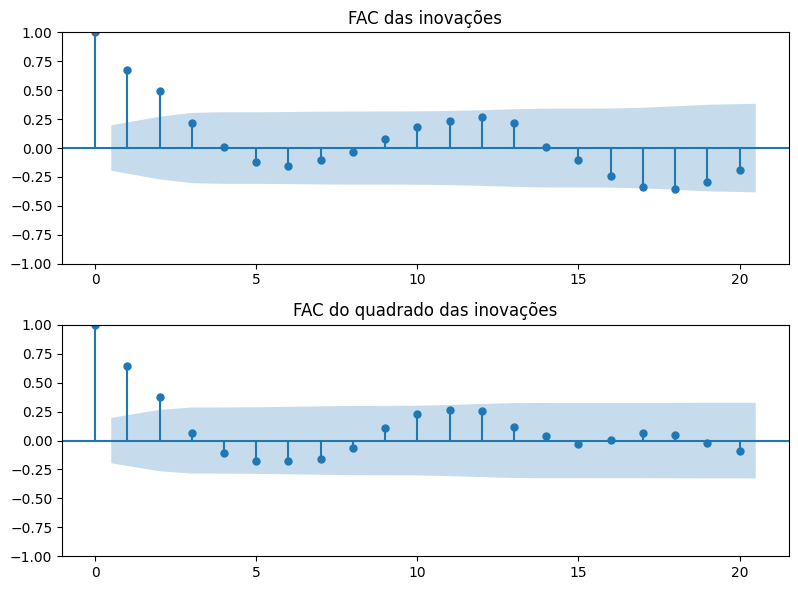

In [16]:
fig, ax = plt.subplots(2, figsize=(8,6))
plot_acf(vt, ax=ax[0], title='FAC das inovações')
plot_acf(vt**2, ax=ax[1], title='FAC do quadrado das inovações')
fig.tight_layout()
plt.show()

## Nível local

$ y_t = \alpha_t + \varepsilon_t,   \varepsilon_t \sim N(0, \sigma_\varepsilon^2)
$   
$
\alpha_{t+1} = \omega + \phi \alpha_{t} + \eta_t ,   \eta_t \sim N(0, \sigma_\eta^2)
$ e $p(\alpha_1) \sim N(a_1, P_1)
$

In [17]:
def particle_kalman_filter_ar1(ω, ϕ, σ_epsilon, σ_eta, y_true, T, N):
    a1 = ω / (1 - ϕ)
    P1 = σ_eta**2 / (1 - ϕ**2)
    
    α_filtered, α_pred = np.zeros(T), np.zeros(T)
    P_filtered, P_pred = np.zeros(T), np.zeros(T)
    α_pred[0] = a1
    P_pred[0] = P1
    
    yi_t = np.zeros(N)
    y_hat = np.zeros(T)
    K_t = np.zeros(T)
    
    for t in range(T):
        # Previsão
        ε_t = rng.normal(0, σ_epsilon, size=N)
        αi_minus = rng.normal(loc=α_pred[t], scale=np.sqrt(P_pred[t]), size=N)
        
        yi_t = αi_minus + ε_t
        y_hat[t] = np.mean(yi_t)
        vt[t] = y_true[t] - y_hat[t]
    
        # Estatísticas para atualização
        F_t = np.mean((yi_t - y_hat[t])**2)
        M_t = np.mean((αi_minus - α_pred[t-1]) * (yi_t - y_hat[t]))  # covariância
    
        # Atualização
        K_t[t] = M_t / F_t
        α_filtered[t] = α_pred[t] + K_t[t] * (y_true[t] - y_hat[t])
        P_filtered[t] = P_pred[t] - K_t[t]**2 * F_t
    
        if t<T-1:
            αi = rng.normal(loc=α_filtered[t], scale=np.sqrt(P_filtered[t]), size=N)
            η_t = rng.normal(0, σ_eta, size=N)
            αi = ω + ϕ * αi + η_t
            α_pred[t+1] = np.mean(αi)
            P_pred[t+1] = np.mean((αi - α_pred[t])**2)
    
    return y_hat, α_filtered, P_filtered, vt

In [18]:
def neg_log_likelihood(theta, y_true, N=1000):
    
    ω, ϕ, log_σ_epsilon, log_σ_eta = theta
    σ_epsilon = np.exp(log_σ_epsilon)
    σ_eta = np.exp(log_σ_eta)
    T = len(y_true)

    y_hat, vt, Ft, _ = particle_kalman_filter_ar1(ω, ϕ, σ_epsilon, σ_eta, y_true, T, N)
    
    Ft = np.maximum(Ft, 1e-6)
    log_likelihood = (
        -T/2 * np.log(2 * np.pi)
        -0.5 * np.sum(np.log(Ft) + (vt**2) / Ft)
    )
    return -log_likelihood

In [19]:
ω = 0.0
ϕ = 0.8
σ_epsilon = 1
σ_eta = 1
T = 100
N = 1000

# Executar o filtro
y_hat, α_hat, P_hat, vt = particle_kalman_filter_ar1(ω, ϕ, σ_epsilon, σ_eta, y_true, T, N)

In [20]:
neg_log_likelihood((ω, ϕ, np.log(σ_epsilon), np.log(σ_eta)), y_true)

296.6107753674677

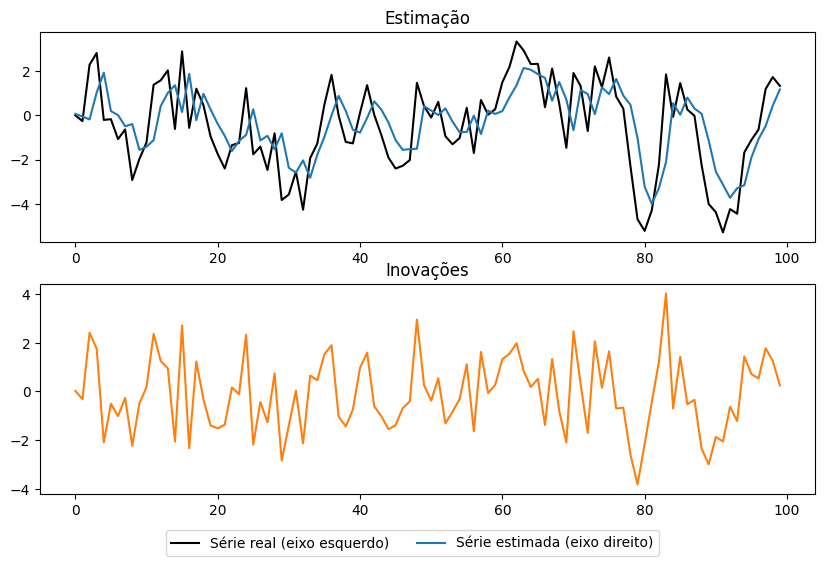

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(10,6))
ax[0].plot(np.arange(T), y_true, label='Série real (eixo esquerdo)', color='black')
ax[0].plot(np.arange(T), y_hat, label='Série estimada (eixo direito)')
ax[0].set_title('Estimação')

ax[1].plot(np.arange(T), vt, color='C1')
ax[1].set_title('Inovações')
fig.legend(loc='lower center', ncol=2)
plt.show()

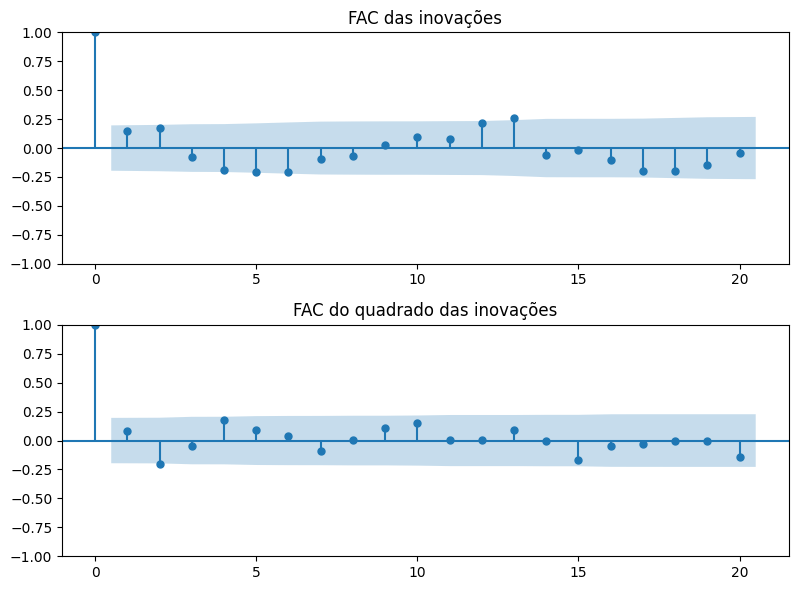

In [22]:
fig, ax = plt.subplots(2, figsize=(8,6))
plot_acf(vt, ax=ax[0], title='FAC das inovações')
plot_acf(vt**2, ax=ax[1], title='FAC do quadrado das inovações')
fig.tight_layout()
plt.show()